# Bag of N grams Tutorial

In [ ]:
# Example of how we use Bag of N grams
from sklearn.feature_extraction.text import CountVectorizer

v= CountVectorizer(ngram_range=(1,2),stop_words="english")
v.fit(["Thor and Loki are looking for a job in Mumbai"])

v.vocabulary_

{'thor': 7,
 'loki': 2,
 'looking': 4,
 'job': 0,
 'mumbai': 6,
 'thor loki': 8,
 'loki looking': 3,
 'looking job': 5,
 'job mumbai': 1}

In [ ]:
# Now Doing work with out Corpus -> first remove stop words and lemmatize the texts and then use CountVector (BoW) of n gram on it
corpus =[
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating Pizza"
]

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")


def preprocess(text):
    doc= nlp(text)

    filtered_tokens =[]
    for token in doc:
        if token.is_stop or token.is_punct: # Skipping stop words and punctuations
            continue
        filtered_tokens.append(token.lemma_) # Lemma gives us the base word

    return " ".join(filtered_tokens) # Converts the list into string seperated by space


# preprocess("Thor ate pizza") # Testing

'thor eat pizza'

In [8]:
corpus_processed =[preprocess(text) for text in corpus]
corpus_processed



['thor eat pizza', 'Loki tall', 'Loki eat Pizza']

In [9]:
v= CountVectorizer(ngram_range=(1,2))
v.fit(corpus_processed)

v.vocabulary_

{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

In [10]:
# Now We can converting text into Vector
v.transform(["Thor eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 1, 1]])

In [11]:
v.transform(["Hulk eat pizza"]).toarray() # But we don't have Hulk in our Vocabulary so it will lead to OOV problem

array([[1, 1, 0, 0, 0, 1, 0, 0, 0]])

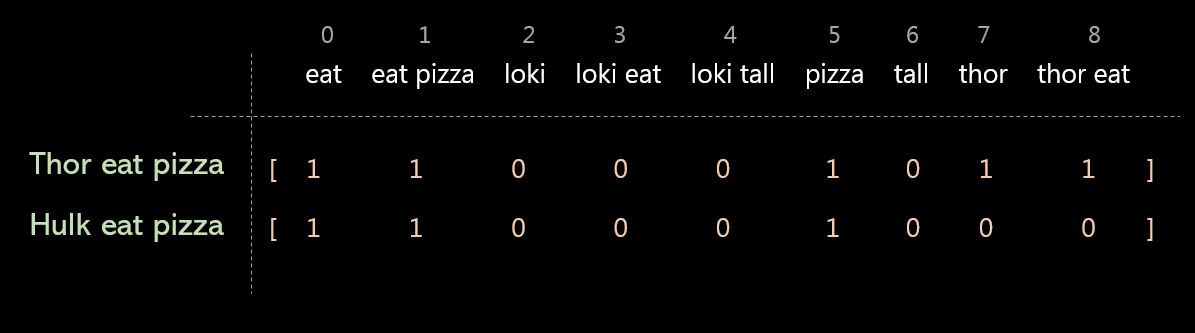

# News Catogory Classifier
* Okay now that we know basics of BAG of n grams vectorizer 😎 It is the time to work on a real problem. Here we want to do a news category classification. We will use bag of n-grams and traing a machine learning model that can categorize any news into one of the following categories,
* BUSINESS
* SPORTS
* CRIME
* SCIENCE
* Dataset - news_dataset.json


In [14]:
import pandas as pd

df = pd.read_json("news_dataset.json")

print(df.shape)
df.head()

(12695, 2)


,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [ ]:
df.category.value_counts() # To check the category wise distribution
# And we can see there is an Imbalance in the categories (Science category is about 1/3 of others)

category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64

In [ ]:
# We are using UnderSampling Technique Here (also we have OverSampling Tech. also)
# Wasting the Training data is a Sin. (But still for now only we just take 1381 samples from each category to maintain balance and discarding all others)

min_samples = 1381
df_business = df[ df.category=='BUSINESS' ].sample(min_samples,random_state=2022)
df_sport = df[ df.category=='SPORTS' ].sample(min_samples,random_state=2022)
df_crime = df[ df.category=='CRIME' ].sample(min_samples,random_state=2022)
df_science = df[ df.category=='SCIENCE' ].sample(min_samples,random_state=2022)

# random_state = When we run this notebook multiple times then it makes sure that the data we have sampled will be consistent in all runs and don't go randomize every time (That will impact in measuring the performance)

In [21]:
df_balanced = pd.concat([df_business,df_sport,df_crime,df_science],axis =0) # axis=0 means row wise
print(df_balanced.head())
print(df_balanced.tail())
df_balanced.category.value_counts()


                                                    text  category
11967  GCC Business Leaders Remain Confident in the F...  BUSINESS
2912   From the Other Side; an Honest Review from Emp...  BUSINESS
3408   Mike McDerment, CEO of FreshBooks, Talks About...  BUSINESS
502    How to Market Your Business While Traveling th...  BUSINESS
5279   How to Leverage Intuition in Decision-making I...  BUSINESS
                                                    text category
2178   Aquarium To Monitor Animals' Behavior Changes ...  SCIENCE
5682   How Google Glass Could Save Lives In The Hospi...  SCIENCE
1643   Honda's Gravity Modification Research For us A...  SCIENCE
11428  EVERYONE Loves Alternative Facts THE POWER OF ...  SCIENCE
8101   From Cooking to Conservation: Women Take Actio...  SCIENCE


category
BUSINESS    1381
SPORTS      1381
CRIME       1381
SCIENCE     1381
Name: count, dtype: int64

In [25]:
# But one more thing before that is : We need to convert the Category into Numbers so that it will split accordingly.
df_balanced['category_num'] = df_balanced.category.map({
    'BUSINESS': 0,
    'SPORTS': 1,
    'CRIME': 2,
    'SCIENCE': 3
})
print(df_balanced.head())
print(df_balanced.tail())

                                                    text  category  \
11967  GCC Business Leaders Remain Confident in the F...  BUSINESS   
2912   From the Other Side; an Honest Review from Emp...  BUSINESS   
3408   Mike McDerment, CEO of FreshBooks, Talks About...  BUSINESS   
502    How to Market Your Business While Traveling th...  BUSINESS   
5279   How to Leverage Intuition in Decision-making I...  BUSINESS   

       category_num  
11967             0  
2912              0  
3408              0  
502               0  
5279              0  
                                                    text category  \
2178   Aquarium To Monitor Animals' Behavior Changes ...  SCIENCE   
5682   How Google Glass Could Save Lives In The Hospi...  SCIENCE   
1643   Honda's Gravity Modification Research For us A...  SCIENCE   
11428  EVERYONE Loves Alternative Facts THE POWER OF ...  SCIENCE   
8101   From Cooking to Conservation: Women Take Actio...  SCIENCE   

       category_num  
2178      

In [ ]:
# Now our Data is balanced and ready to Train-Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    df_balanced.text, # X part
    df_balanced.category_num, # Y-part
    test_size=0.2, # 80-20 Train-Test Size
    random_state=2022, # Make data consistent in every run
    stratify= df_balanced.category_num # IMP- Stratify will create equal no. of samples from all class in Test and Train both
)


In [28]:
print(X_train.shape)
print(X_train.head())

(4419,)
7589     Ovulating Women Prefer Images of Penetration O...
10442    Scientists Discover Spooky Influence On Baby N...
8792     Olympic Race Walker Steps Up To Propose To His...
1733     Beloved Bipedal Bear Named Pedals Believed Kil...
2526     Elizabeth Smart Gave Birth To Baby Girl, Fathe...
Name: text, dtype: str


In [ ]:
print("Y train size: ",y_train.shape)
print(y_train.value_counts())
print("Y test size: ",y_test.shape)
print(y_test.value_counts())
# So bcz of Stratify, We have samples from all category.
# So, the model is not baised only for 1 or 2 category

Y train size:  (4419,)
category_num
3    1105
2    1105
0    1105
1    1104
Name: count, dtype: int64
Y test size:  (1105,)
category_num
1    277
0    276
3    276
2    276
Name: count, dtype: int64


In [55]:
#  Now we are using Naive Bayes Classifier to Classify the News Category Problem
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

clf = Pipeline([
    ('vectorizer_bow',CountVectorizer()), # Unigramn N-bag of word
    ('nb',MultinomialNB())
])

clf.fit(X_train,y_train)

y_pred1 = clf.predict(X_test)
print(classification_report(y_test,y_pred1))



              precision    recall  f1-score   support

           0       0.75      0.87      0.81       276
           1       0.93      0.80      0.86       277
           2       0.83      0.90      0.86       276
           3       0.90      0.80      0.85       276

    accuracy                           0.84      1105
   macro avg       0.85      0.84      0.84      1105
weighted avg       0.85      0.84      0.84      1105



In [56]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

clf = Pipeline([
    ('vectorizer_bow',CountVectorizer(ngram_range=(1,2))), # Unigram + Bigramn N-bag of word
    ('nb',MultinomialNB())
])

clf.fit(X_train,y_train)

y_pred2 = clf.predict(X_test)
print(classification_report(y_test,y_pred2))


              precision    recall  f1-score   support

           0       0.69      0.90      0.78       276
           1       0.95      0.74      0.83       277
           2       0.82      0.88      0.85       276
           3       0.92      0.78      0.84       276

    accuracy                           0.82      1105
   macro avg       0.85      0.82      0.83      1105
weighted avg       0.85      0.82      0.83      1105



In [57]:
X_test[:5]

3716     African Nation Slaps Exxon With Fine Nearly 7 ...
608      These Cringe-Worthy Stories Show It Can Be Har...
11172    LISTEN: The Accidental Discovery That Proved T...
1346     Build Loyalty -- The Cost -- $00.00 Remember y...
1356     Man Killed By Michigan Police Wasn't Targeting...
Name: text, dtype: str

In [58]:
y_test[:5]

3716     0
608      3
11172    3
1346     0
1356     2
Name: category_num, dtype: int64

In [ ]:
print(y_pred1[:5]) # As Unigram performance is good we can see from its accuracy
print(y_pred2[:5])

[0 3 3 0 2]
[0 0 3 0 2]


In [60]:
# Whatever we have done now is with the Unprocessed text in the df_balanced.text content
# So, Now let we Pre-process the text and then see the results
# Preprocess function we have already created in the starting of the tutorial 
# that function removes the stop words and also lemmatizes the text

df_balanced['preprocessed_text'] = df_balanced.text.apply(preprocess)
df_balanced.head()

,text,category,category_num,preprocessed_text
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0,GCC Business leader remain confident Face Regi...
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0,Honest Review Employees wake morning love impo...
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0,Mike McDerment CEO FreshBooks Talks give build...
502,How to Market Your Business While Traveling th...,BUSINESS,0,market business travel World recently amazing ...
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0,leverage intuition decision making feel safe r...


In [62]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    df_balanced.preprocessed_text, # X part as Preprocessed Text
    df_balanced.category_num, # Y-part
    test_size=0.2, # 80-20 Train-Test Size
    random_state=2022, # Make data consistent in every run
    stratify= df_balanced.category_num # IMP- Stratify will create equal no. of samples from all class in Test and Train both
)

clf = Pipeline([
    ('vectorizer',CountVectorizer()),
    ('nb',MultinomialNB())
])

clf.fit(X_train,y_train)

y_pred3= clf.predict(X_test)
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       276
           1       0.93      0.82      0.87       277
           2       0.81      0.91      0.86       276
           3       0.91      0.83      0.87       276

    accuracy                           0.86      1105
   macro avg       0.86      0.86      0.86      1105
weighted avg       0.86      0.86      0.86      1105



* We can see that the Accuracy has improved and now it is 86%

In [63]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred3)
cm

array([[240,   8,  17,  11],
       [  8, 226,  36,   7],
       [ 17,   3, 252,   4],
       [ 34,   6,   6, 230]])

Text(33.33333333333333, 0.5, 'Truth')

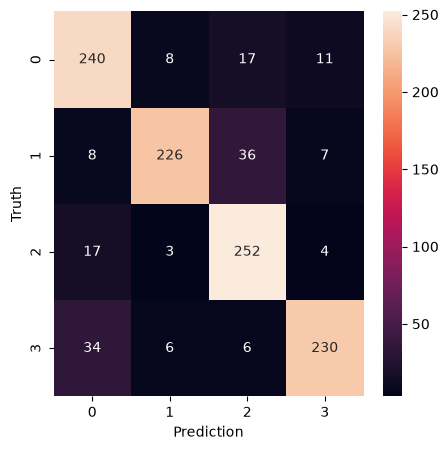

In [68]:
# %pip install matplotlib
# %pip install seaborn
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')


* The confusion matrix shows the model’s actual vs predicted classes. 
* The diagonal values represent correct predictions.
* While the off-diagonal values represent misclassifications

Correct prediction example:

Truth = 0, Prediction = 0 → 240

* ➡️ 240 samples were actually class 0 and the model correctly predicted 0.

Wrong prediction example:

Truth = 1, Prediction = 2 → 36

* ➡️ 36 samples were actually class 1, but the model predicted 2.

# Overall we achieved a 86% Accuracy in the News Category Classification Problem